# Word2Vec (2/3): Embeddings “a mano” — Skip-gram con Negative Sampling (SGNS)

En este notebook implementamos **Word2Vec Skip-gram con Negative Sampling** (SGNS) *desde cero* usando solo `numpy`.
La meta es entender **la red neuronal mínima** que aprende embeddings y cómo el **contexto** guía el aprendizaje.

## Objetivos
Al finalizar, podrás:
- Construir el dataset de pares *(centro, contexto)* con ventana.
- Implementar el modelo SGNS con matrices `W_in` y `W_out`.
- Entrenar con descenso por gradiente (SGD).
- Inspeccionar similitudes y hacer analogías tipo: **rey − hombre + mujer ≈ reina**.

> Nota: el corpus es pequeño y didáctico. En corpora reales, se usan optimizaciones y grandes cantidades de texto.


## 0. Setup (spaCy + numpy)

Si no tienes el modelo en español instalado:

```bash
python -m spacy download es_core_news_sm
```


In [1]:
from __future__ import annotations

import math
from collections import Counter
from dataclasses import dataclass
from typing import Dict, List, Sequence, Tuple

import numpy as np
import matplotlib.pyplot as plt

import spacy


In [2]:
def load_spacy_model(preferred: str = "es_core_news_sm"):
    try:
        return spacy.load(preferred)
    except Exception:
        lang = preferred.split("_")[0] if "_" in preferred else "es"
        print(
            f"[WARN] Could not load '{preferred}'. Falling back to spacy.blank('{lang}').\n"
            f"       To install the model: python -m spacy download {preferred}"
        )
        return spacy.blank(lang)


nlp = load_spacy_model("es_core_news_sm")


## 1. Corpus didáctico

Para que la analogía “rey − hombre + mujer ≈ reina” tenga chance de aparecer en un corpus pequeño,
necesitamos frases que impongan **patrones de contexto consistentes**.

Puedes editar/expandir estas frases libremente.


In [3]:
corpus_sentences = [
    "El rey es un hombre.",
    "La reina es una mujer.",
    "El rey gobierna el reino.",
    "La reina gobierna el reino.",
    "El príncipe es un hombre.",
    "La princesa es una mujer.",
    "El príncipe vive en el reino.",
    "La princesa vive en el reino.",
    "El hombre trabaja.",
    "La mujer trabaja.",
    "El rey y la reina viven en el palacio.",
    "El príncipe y la princesa viven en el palacio.",
    "El rey visita el palacio.",
    "La reina visita el palacio.",
    "El príncipe visita el palacio.",
    "La princesa visita el palacio.",
]

print(f"N sentences: {len(corpus_sentences)}")
print("\n".join(corpus_sentences[:6]))


N sentences: 16
El rey es un hombre.
La reina es una mujer.
El rey gobierna el reino.
La reina gobierna el reino.
El príncipe es un hombre.
La princesa es una mujer.


## 2. Tokenización (spaCy) y vocabulario

Normalizamos a minúsculas y removemos puntuación/espacios.
Por defecto **no removemos stopwords** para mantener “frases” más reconocibles.


In [4]:
def tokenize_sentences(sentences: Sequence[str], nlp_obj, *, remove_stop: bool = False) -> List[List[str]]:
    tokenized: List[List[str]] = []
    for s in sentences:
        doc = nlp_obj(s)
        toks: List[str] = []
        for t in doc:
            if t.is_space or t.is_punct:
                continue
            if remove_stop and t.is_stop:
                continue
            toks.append(t.text.lower())
        tokenized.append(toks)
    return tokenized


tokenized = tokenize_sentences(corpus_sentences, nlp, remove_stop=False)
tokenized[:3]


[['el', 'rey', 'es', 'un', 'hombre'],
 ['la', 'reina', 'es', 'una', 'mujer'],
 ['el', 'rey', 'gobierna', 'el', 'reino']]

In [5]:
def build_vocab(tokenized_sents: Sequence[Sequence[str]], min_freq: int = 1) -> Tuple[List[str], Dict[str, int]]:
    counts = Counter(w for sent in tokenized_sents for w in sent)
    vocab = [w for w, c in counts.items() if c >= min_freq]
    vocab.sort()
    word2id = {w: i for i, w in enumerate(vocab)}
    return vocab, word2id


vocab, word2id = build_vocab(tokenized, min_freq=1)
id2word = {i: w for w, i in word2id.items()}
print(f"Vocab size: {len(vocab)}")
vocab[:30]


Vocab size: 20


['el',
 'en',
 'es',
 'gobierna',
 'hombre',
 'la',
 'mujer',
 'palacio',
 'princesa',
 'príncipe',
 'reina',
 'reino',
 'rey',
 'trabaja',
 'un',
 'una',
 'visita',
 'vive',
 'viven',
 'y']

## 3. Dataset Skip-gram: pares (centro, contexto)

Con ventana `window = c`, para cada palabra central `w_t` generamos pares con cada palabra en su contexto.


In [6]:
@dataclass(frozen=True)
class Pair:
    center_id: int
    context_id: int


def generate_pairs(tokenized_sents: Sequence[Sequence[str]], word2id_map: Dict[str, int], window: int) -> List[Pair]:
    pairs: List[Pair] = []
    for sent in tokenized_sents:
        ids = [word2id_map[w] for w in sent if w in word2id_map]
        n = len(ids)
        for i, c_id in enumerate(ids):
            left = max(0, i - window)
            right = min(n, i + window + 1)
            for j in range(left, right):
                if j == i:
                    continue
                pairs.append(Pair(center_id=c_id, context_id=ids[j]))
    return pairs


window = 2
pairs = generate_pairs(tokenized, word2id, window=window)
print(f"Pairs: {len(pairs)}")
pairs[:8]


Pairs: 248


[Pair(center_id=0, context_id=12),
 Pair(center_id=0, context_id=2),
 Pair(center_id=12, context_id=0),
 Pair(center_id=12, context_id=2),
 Pair(center_id=12, context_id=14),
 Pair(center_id=2, context_id=0),
 Pair(center_id=2, context_id=12),
 Pair(center_id=2, context_id=14)]

## 4. Modelo SGNS: la red neuronal mínima

Word2Vec SGNS mantiene **dos matrices de embeddings**:

- `W_in`  (V × D): embedding cuando la palabra es **central**
- `W_out` (V × D): embedding cuando la palabra es **contexto**

Para un par positivo (centro `c`, contexto `o`), queremos que el producto punto `u_o · v_c` sea grande.
Para pares negativos (centro `c`, “contextos falsos” `n`), queremos que `u_n · v_c` sea pequeño.

### Pérdida (por un par positivo)
Con `K` negativos:

L = -log σ(u_o^T v_c) - Σ log σ(-u_n^T v_c)


In [7]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    x = np.clip(x, -20, 20)
    return 1.0 / (1.0 + np.exp(-x))


def cosine_similarity(a: np.ndarray, b: np.ndarray, eps: float = 1e-12) -> float:
    return float((a @ b) / ((np.linalg.norm(a) * np.linalg.norm(b)) + eps))


## 5. Negative sampling: distribución de muestreo

Se muestrean negativos con:

P(w) ∝ f(w)^0.75


In [8]:
def negative_sampling_distribution(tokenized_sents: Sequence[Sequence[str]], word2id_map: Dict[str, int], power: float = 0.75) -> np.ndarray:
    counts = Counter(w for sent in tokenized_sents for w in sent if w in word2id_map)
    freqs = np.zeros(len(word2id_map), dtype=np.float64)
    for w, c in counts.items():
        freqs[word2id_map[w]] = float(c)
    probs = np.power(freqs, power)
    probs = probs / probs.sum()
    return probs


neg_probs = negative_sampling_distribution(tokenized, word2id, power=0.75)
float(neg_probs.sum())


1.0000000000000002

## 6. Entrenamiento SGNS (SGD)

Loop simple:
- barajamos los pares
- por cada par:
  - muestreamos `K` negativos
  - actualizamos solo los embeddings involucrados


In [9]:
def train_sgns(
    pairs: Sequence[Pair],
    vocab_size: int,
    dim: int = 50,
    epochs: int = 50,
    lr: float = 0.05,
    num_neg: int = 5,
    neg_probs: np.ndarray | None = None,
    seed: int = 7,
    verbose_every: int = 10,
) -> Tuple[np.ndarray, np.ndarray, List[float]]:
    rng = np.random.default_rng(seed)

    W_in = rng.normal(0.0, 0.1, size=(vocab_size, dim)).astype(np.float64)
    W_out = rng.normal(0.0, 0.1, size=(vocab_size, dim)).astype(np.float64)

    if neg_probs is None:
        neg_probs = np.ones(vocab_size, dtype=np.float64) / vocab_size

    losses: List[float] = []
    pairs_list = list(pairs)

    for ep in range(1, epochs + 1):
        rng.shuffle(pairs_list)
        total_loss = 0.0

        for p in pairs_list:
            c = p.center_id
            o = p.context_id

            v_c = W_in[c]
            u_o = W_out[o]

            score_pos = float(u_o @ v_c)
            sig_pos = float(sigmoid(np.array(score_pos)))

            neg_ids = rng.choice(vocab_size, size=num_neg, replace=True, p=neg_probs)
            for i in range(len(neg_ids)):
                if neg_ids[i] == o:
                    neg_ids[i] = int(rng.choice(vocab_size, p=neg_probs))

            u_negs = W_out[neg_ids]
            scores_neg = u_negs @ v_c
            sig_neg = sigmoid(-scores_neg)

            eps = 1e-12
            total_loss += -math.log(sig_pos + eps) - float(np.sum(np.log(sig_neg + eps)))

            g_pos = (sig_pos - 1.0)          # scalar
            g_negs = (1.0 - sig_neg)         # (K,)

            # Updates
            W_out[o] -= lr * g_pos * v_c
            W_out[neg_ids] -= lr * (g_negs[:, None] * v_c[None, :])

            grad_v = g_pos * u_o + np.sum(g_negs[:, None] * u_negs, axis=0)
            W_in[c] -= lr * grad_v

        avg_loss = total_loss / max(1, len(pairs_list))
        losses.append(avg_loss)

        if verbose_every > 0 and (ep == 1 or ep % verbose_every == 0 or ep == epochs):
            print(f"Epoch {ep:>3}/{epochs} | avg loss: {avg_loss:.4f}")

    return W_in, W_out, losses


W_in, W_out, losses = train_sgns(
    pairs=pairs,
    vocab_size=len(vocab),
    dim=40,
    epochs=80,
    lr=0.05,
    num_neg=6,
    neg_probs=neg_probs,
    seed=7,
    verbose_every=10,
)


Epoch   1/80 | avg loss: 4.6126
Epoch  10/80 | avg loss: 2.4262
Epoch  20/80 | avg loss: 2.3214
Epoch  30/80 | avg loss: 2.5095
Epoch  40/80 | avg loss: 2.5872
Epoch  50/80 | avg loss: 2.8577
Epoch  60/80 | avg loss: 3.2360
Epoch  70/80 | avg loss: 3.4998
Epoch  80/80 | avg loss: 4.3995


In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.title("SGNS training loss (avg per epoch)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


## 7. Vecinos semánticos (cosine similarity)

Usaremos `E = W_in` como embedding final (puedes probar `W_in + W_out`).


In [10]:
E = W_in  # try: E = W_in + W_out


In [11]:
def most_similar(word: str, E: np.ndarray, word2id_map: Dict[str, int], id2word_map: Dict[int, str], top_k: int = 8):
    if word not in word2id_map:
        raise KeyError(f"'{word}' not in vocabulary.")
    i = word2id_map[word]
    sims: List[Tuple[str, float]] = []
    for j in range(E.shape[0]):
        if j == i:
            continue
        sims.append((id2word_map[j], cosine_similarity(E[i], E[j])))
    sims.sort(key=lambda x: x[1], reverse=True)
    return sims[:top_k]


for w in ["rey", "reina", "hombre", "mujer", "príncipe", "princesa", "reino", "palacio"]:
    print(w, "→", most_similar(w, E, word2id, id2word, top_k=6))


rey → [('el', 0.8458263170700044), ('reina', 0.8424688924317024), ('la', 0.8153668716823917), ('hombre', 0.81443230078246), ('reino', 0.8036209580537164), ('príncipe', 0.803504043817114)]
reina → [('princesa', 0.8989871272341845), ('el', 0.8937487811200988), ('mujer', 0.8425367135453176), ('rey', 0.8424688924317024), ('la', 0.8285668728858495), ('reino', 0.826097661524074)]
hombre → [('mujer', 0.8941545064196185), ('el', 0.8521342922934128), ('príncipe', 0.8505857384844607), ('rey', 0.81443230078246), ('una', 0.8102010408968225), ('visita', 0.808763019977216)]
mujer → [('hombre', 0.8941545064196185), ('visita', 0.8800109220012011), ('el', 0.8538043700378021), ('reina', 0.8425367135453176), ('princesa', 0.8421751158954504), ('una', 0.8204002109155022)]
príncipe → [('princesa', 0.8695338274157179), ('hombre', 0.8505857384844607), ('el', 0.8448412212287228), ('rey', 0.803504043817114), ('vive', 0.765412490962807), ('en', 0.7640401047414049)]
princesa → [('reina', 0.8989871272341845), ('el

## 8. Analogías vectoriales

Buscamos el vector objetivo:

target = sum(positive) - sum(negative)

y retornamos las palabras más cercanas por cosine similarity.


In [12]:
def analogy(
    positive: Sequence[str],
    negative: Sequence[str],
    E: np.ndarray,
    word2id_map: Dict[str, int],
    id2word_map: Dict[int, str],
    top_k: int = 5,
) -> List[Tuple[str, float]]:
    for w in list(positive) + list(negative):
        if w not in word2id_map:
            raise KeyError(f"'{w}' not in vocabulary.")

    target = np.zeros(E.shape[1], dtype=np.float64)
    for w in positive:
        target += E[word2id_map[w]]
    for w in negative:
        target -= E[word2id_map[w]]

    excluded = {word2id_map[w] for w in list(positive) + list(negative)}

    sims: List[Tuple[str, float]] = []
    for j in range(E.shape[0]):
        if j in excluded:
            continue
        sims.append((id2word_map[j], cosine_similarity(target, E[j])))
    sims.sort(key=lambda x: x[1], reverse=True)
    return sims[:top_k]


analogy(["rey", "mujer"], ["hombre"], E, word2id, id2word, top_k=8)


[('reina', 0.8858376283121656),
 ('visita', 0.8261592601779835),
 ('el', 0.8206637869097173),
 ('princesa', 0.7931809687865845),
 ('la', 0.7822816685258147),
 ('y', 0.7735150897219928),
 ('palacio', 0.7687523630051869),
 ('reino', 0.7595102232259228)]

In [13]:
print("príncipe - hombre + mujer →", analogy(["príncipe", "mujer"], ["hombre"], E, word2id, id2word, top_k=6))
print("reina - mujer + hombre →", analogy(["reina", "hombre"], ["mujer"], E, word2id, id2word, top_k=6))


príncipe - hombre + mujer → [('princesa', 0.9355034364468384), ('el', 0.8524052222954166), ('reina', 0.8286094429728457), ('en', 0.8024401549337841), ('visita', 0.8004226087560732), ('viven', 0.7973186436959536)]
reina - mujer + hombre → [('rey', 0.8835510974316191), ('el', 0.8665895059325339), ('príncipe', 0.8225976033755404), ('reino', 0.8185293450776413), ('princesa', 0.8180852154070323), ('la', 0.810079353545219)]


## 9. Visualización (PCA 2D)

Proyectamos embeddings a 2D con PCA para ver agrupamientos.


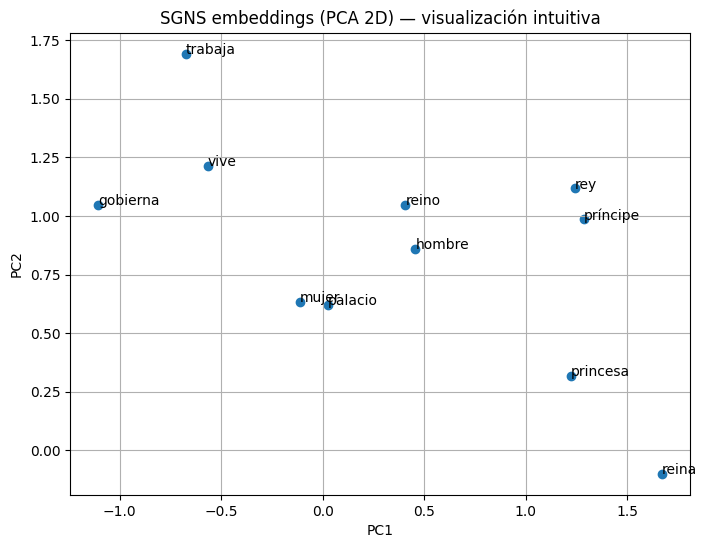

In [14]:
def pca_2d(X: np.ndarray) -> np.ndarray:
    Xc = X - X.mean(axis=0, keepdims=True)
    cov = (Xc.T @ Xc) / max(1, Xc.shape[0] - 1)
    vals, vecs = np.linalg.eigh(cov)
    W = vecs[:, -2:]
    return Xc @ W


E2 = pca_2d(E)


def plot_words(E2d: np.ndarray, words: Sequence[str], word2id_map: Dict[str, int]):
    xs, ys, labs = [], [], []
    for w in words:
        if w not in word2id_map:
            continue
        i = word2id_map[w]
        xs.append(E2d[i, 0])
        ys.append(E2d[i, 1])
        labs.append(w)

    plt.figure(figsize=(8, 6))
    plt.scatter(xs, ys)
    for x, y, lab in zip(xs, ys, labs):
        plt.text(x, y, lab, fontsize=10)
    plt.title("SGNS embeddings (PCA 2D) — visualización intuitiva")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()


words_to_plot = ["rey", "reina", "hombre", "mujer", "príncipe", "princesa", "reino", "palacio", "gobierna", "vive", "trabaja"]
plot_words(E2, words_to_plot, word2id)


## 10. Resumen

- SGNS entrena embeddings aprendiendo a distinguir pares reales (centro, contexto) vs pares negativos.
- Las matrices `W_in` y `W_out` son los parámetros del modelo.
- La estructura semántica emerge porque palabras con contextos similares reciben gradientes similares.
- Las analogías aparecen cuando ciertas relaciones se vuelven aproximadamente lineales en el espacio.

En el Notebook 3 usaremos **gensim** (y opcionalmente spaCy para preprocesar) para entrenar Word2Vec “como se hace en la práctica”.


## 11. Ejercicios

1) Cambia `dim` a 20 y 80. ¿Mejoran vecinos/analogías?  
2) Cambia `window` a 1 y 3. ¿Qué relaciones se fortalecen?  
3) Prueba `E = W_in + W_out`. ¿Qué cambia?  
4) Aumenta el corpus con frases adicionales que refuercen “roles” y “género”.  
5) (Reto) Implementa **subsampling** de palabras frecuentes (como en Word2Vec original).
